In [12]:
# Insttall & import Liberaries 

# 0.1 install missing liberaries (run once)

import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'openpyxl']:
 subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All libraries are ready!')


All libraries are ready!


In [8]:
# 0.2 Import All Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries imported successfully!')


Libraries imported successfully!


In [9]:
# STAGE 1_UNDERSTANDING THE DATASET 
# 1.1 Load the dataset 
df = pd.read_excel('sales_records_dataset.xlsx')
print(f'Dataset loaded! Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded! Shape: 1000 rows × 14 columns


In [7]:
# 1.2 Previwe the first 5 rows
df.head()


,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaN,Cash,Rep_B
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D


In [8]:
# 1.3 Check column name and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          955 non-null    object 
 1   Customer_Name     956 non-null    object 
 2   Gender            949 non-null    object 
 3   Region            941 non-null    object 
 4   Product_Category  944 non-null    object 
 5   Product_Name      961 non-null    object 
 6   Quantity          955 non-null    float64
 7   Unit_Price        949 non-null    float64
 8   Total_Sales       942 non-null    float64
 9   Discount          950 non-null    float64
 10  Profit            947 non-null    float64
 11  Order_Date        945 non-null    object 
 12  Payment_Method    944 non-null    object 
 13  Sales_Rep         955 non-null    object 
dtypes: float64(5), object(9)
memory usage: 109.5+ KB


In [10]:
# 1.4 Statistical summary of numeric columns
df.describe().round(2)

,Quantity,Unit_Price,Total_Sales,Discount,Profit
count,955.00,949.00,942.00,950.00,947.00
mean,5.53,75752.28,424735.26,2513.22,64645.40
std,2.85,42736.95,339359.57,1463.39,61028.39
min,1.00,2037.00,2118.00,0.00,171.57
25%,3.00,38059.00,133941.50,1271.00,17417.64
50%,6.00,76180.00,357334.50,2497.50,46940.54
75%,8.00,112145.00,621387.25,3796.25,93647.07
max,10.00,149555.00,1492040.00,4996.00,356652.16


In [11]:
# 1.5 Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %',
ascending=False)
print('Columns with missing values:')
print(missing_df.to_string())

Columns with missing values:
                  Missing Count  Missing %
Region                       59        5.9
Total_Sales                  58        5.8
Product_Category             56        5.6
Payment_Method               56        5.6
Order_Date                   55        5.5
Profit                       53        5.3
Gender                       51        5.1
Unit_Price                   51        5.1
Discount                     50        5.0
Order_ID                     45        4.5
Quantity                     45        4.5
Sales_Rep                    45        4.5
Customer_Name                44        4.4
Product_Name                 39        3.9


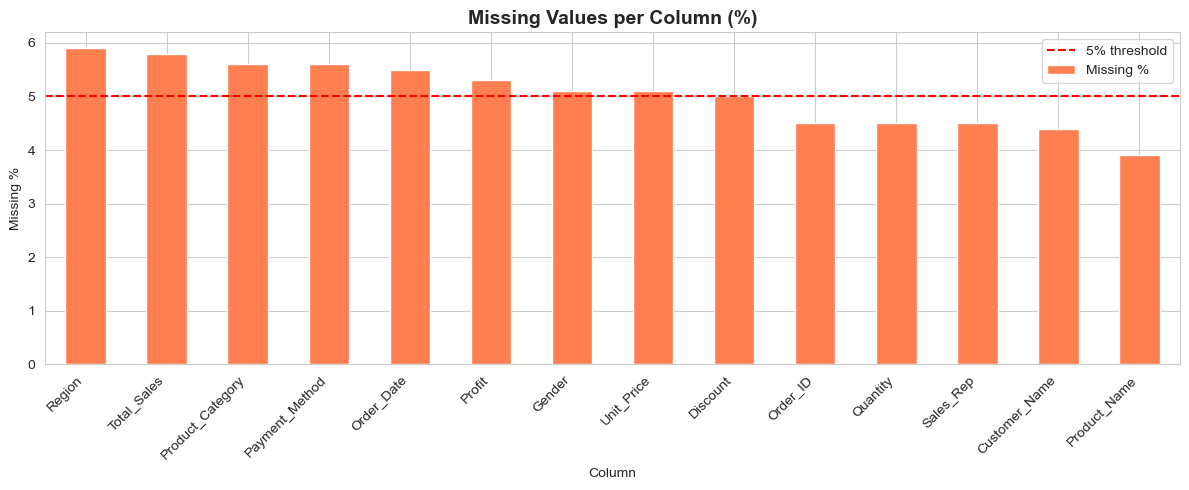

In [12]:
# 1.6 Visualise missing values as a bar chart 
fig, ax = plt.subplots(figsize=(12, 5))
missing_df['Missing %'].plot(kind='bar', color='coral', ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.axhline(5, color='red', linestyle='--', label='5% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Check for duplicate row 
dupes = df.duplicated().sum()
print(f'Number of fully duplicate rows: {dupes}')

Number of fully duplicate rows: 0


In [12]:
# STAGE 2 _ DATA CLEANING 
# 2.1 Make a working copy 

df_clean = df.copy()
print(f'Working copy created. Shape: {df_clean.shape}')

Working copy created. Shape: (1000, 14)


In [13]:
# 2.2 Fix the order _ data column (text---> datatime)
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], errors='coerce')
print('Order_Date dtype after fix:', df_clean['Order_Date'].dtype)
print('Sample dates:', df_clean['Order_Date'].dropna().head(5).tolist())

Order_Date dtype after fix: datetime64[ns]
Sample dates: [Timestamp('2022-07-18 00:00:00'), Timestamp('2024-09-18 00:00:00'), Timestamp('2023-09-11 00:00:00'), Timestamp('2022-06-03 00:00:00'), Timestamp('2023-07-12 00:00:00')]


In [14]:
# 2.3  Remove duplicate rows 
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Rows before: {before} | After: {after} | Removed: {before - after}')

Rows before: 1000 | After: 1000 | Removed: 0


In [15]:
# 2.4 Handle missing value in NUMERIC columns
df_clean['Quantity'] = df_clean['Quantity'].fillna(df_clean['Quantity'].median())
df_clean['Unit_Price'] = df_clean['Unit_Price'].fillna(df_clean['Unit_Price'].median())
df_clean['Total_Sales'] = df_clean['Total_Sales'].fillna(df_clean['Total_Sales'].median())
df_clean['Profit'] = df_clean['Profit'].fillna(df_clean['Profit'].median())
df_clean['Discount'] = df_clean['Discount'].fillna(0)
print('Numeric columns — remaining missing values:')
print(df_clean[['Quantity','Unit_Price','Total_Sales','Profit','Discount']].isnull(
).sum())

Numeric columns — remaining missing values:
Quantity       0
Unit_Price     0
Total_Sales    0
Profit         0
Discount       0
dtype: int64


In [16]:
# 2.5 Handle missing values in CATEGORICAL columns 
for col in ['Gender', 'Region', 'Product_Category', 'Payment_Method']:
 mode_val = df_clean[col].mode()[0]
 df_clean[col].fillna(mode_val, inplace=True)
for col in ['Sales_Rep', 'Customer_Name', 'Order_ID', 'Product_Name']:
 df_clean[col].fillna('Unknown', inplace=True)
 df_clean.dropna(subset=['Order_Date'], inplace=True)
print('Remaining missing values after cleaning:')
print(df_clean.isnull().sum())

Remaining missing values after cleaning:
Order_ID            0
Customer_Name       0
Gender              0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Total_Sales         0
Discount            0
Profit              0
Order_Date          0
Payment_Method      0
Sales_Rep           0
dtype: int64


In [17]:
# 2.6 Add derived (engineered) columns
df_clean['Year'] = df_clean['Order_Date'].dt.year
df_clean['Month'] = df_clean['Order_Date'].dt.month
df_clean['Month_Name'] = df_clean['Order_Date'].dt.strftime('%b')
df_clean['Quarter'] = df_clean['Order_Date'].dt.to_period('Q').astype(str)
df_clean['Profit_Margin'] = (df_clean['Profit'] / df_clean['Total_Sales'] *
100).round(2)
print('New columns added:',
['Year','Month','Month_Name','Quarter','Profit_Margin'])
df_clean[['Order_Date','Year','Month','Month_Name','Quarter','Profit_Margin']].head
()

New columns added: ['Year', 'Month', 'Month_Name', 'Quarter', 'Profit_Margin']


()

In [18]:
# 2.7 Final check after cleaning
print(f'Clean dataset shape: {df_clean.shape}')
print(f'Rows removed during cleaning: {len(df) - len(df_clean)}')
df_clean.head(3)

Clean dataset shape: (945, 19)
Rows removed during cleaning: 55


,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep,Year,Month,Month_Name,Quarter,Profit_Margin
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D,2022,7,Jul,2022Q3,18.19
1,Unknown,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A,2024,9,Sep,2024Q3,12.94
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C,2023,9,Sep,2023Q3,5.87


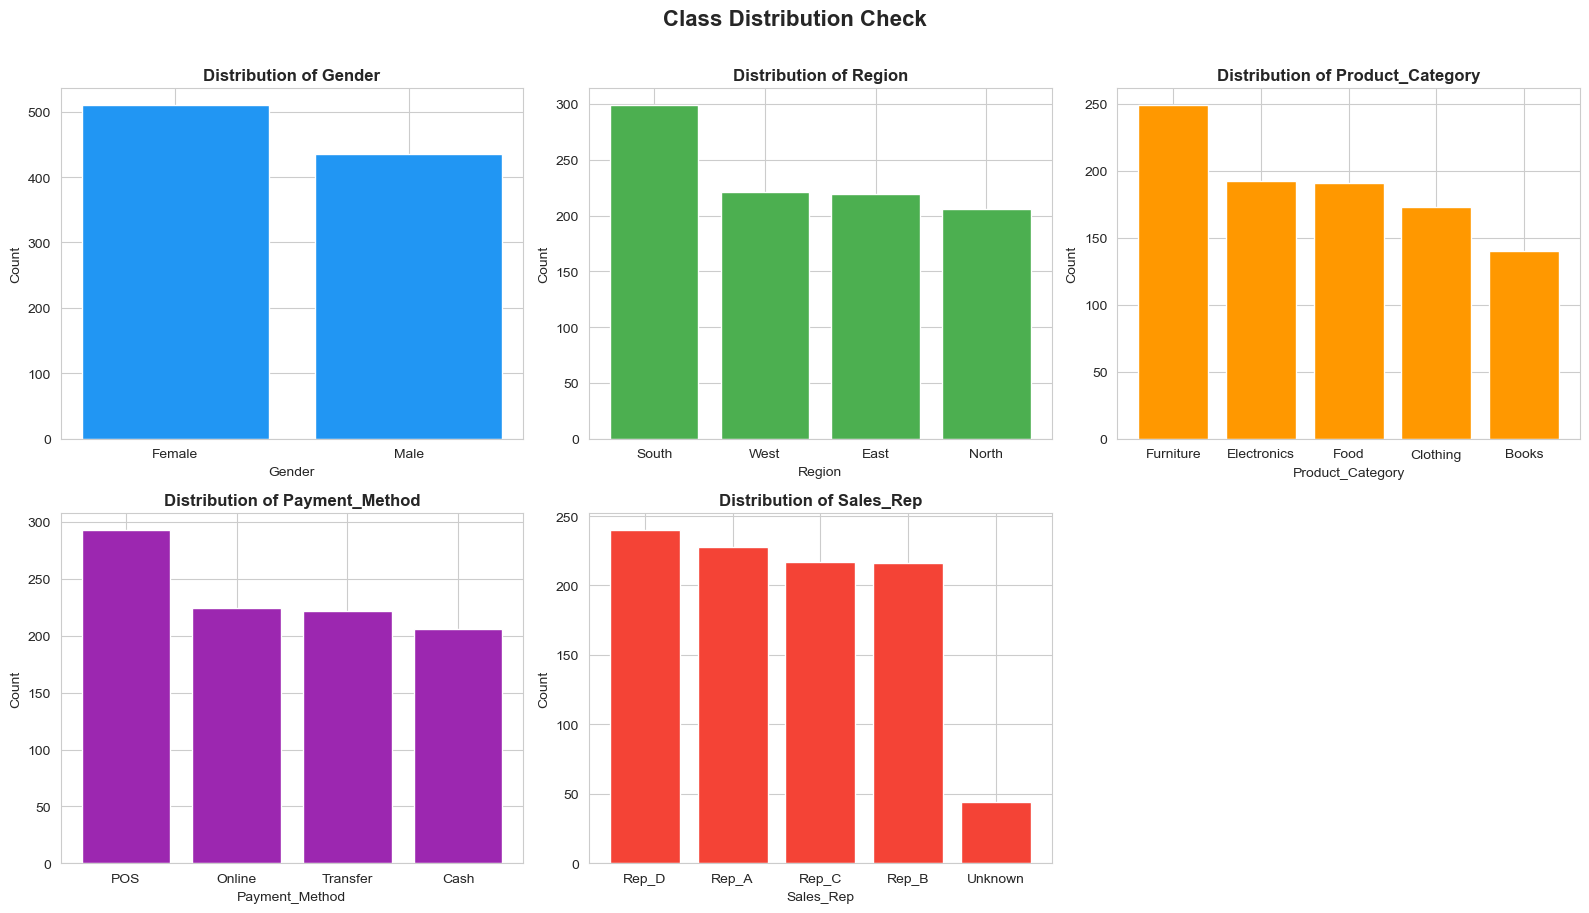

In [19]:
# STAGE 3 — Checking & Balancing the Dataset
# 3.1 Check distribution of key categorical columns
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
for i, col in enumerate(cat_cols):
 counts = df_clean[col].value_counts()
 axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='white')
 axes[i].set_title(f'Distribution of {col}', fontweight='bold')
 axes[i].set_xlabel(col)
 axes[i].set_ylabel('Count')
for j, v in enumerate(counts.values):
 axes[5].set_visible(False)
plt.suptitle('Class Distribution Check', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# 3.2 Measure imbalance ratio
print('Imbalance Ratios (max / min count per category)\n')
for col in cat_cols:
 counts = df_clean[col].value_counts()
 ratio = counts.max() / counts.min()
 status = 'Balanced' if ratio <= 2.0 else '⚠️ Imbalanced'
print(f'{col:<20} Ratio: {ratio:.2f} {status}')

Imbalance Ratios (max / min count per category)

Sales_Rep            Ratio: 5.45 ⚠️ Imbalanced


In [21]:
# 3.3 Optional: Undersample to balance (demo)
APPLY_BALANCING = False # Change to True to activate
BALANCE_COLUMN = 'Product_Category'
if APPLY_BALANCING:
  min_count = df_clean[BALANCE_COLUMN].value_counts().min()
  df_balanced = (df_clean.groupby(BALANCE_COLUMN)
    .apply(lambda x: x.sample(min_count, random_state=42))
         .reset_index(drop=True)
)
  print(f'Balanced shape: {df_balanced.shape}')
  print(df_balanced[BALANCE_COLUMN].value_counts())
else:
 df_balanced = df_clean.copy()
 print('Using the full cleaned dataset.')
 print(f'Shape: {df_balanced.shape}')

Using the full cleaned dataset.
Shape: (945, 19)


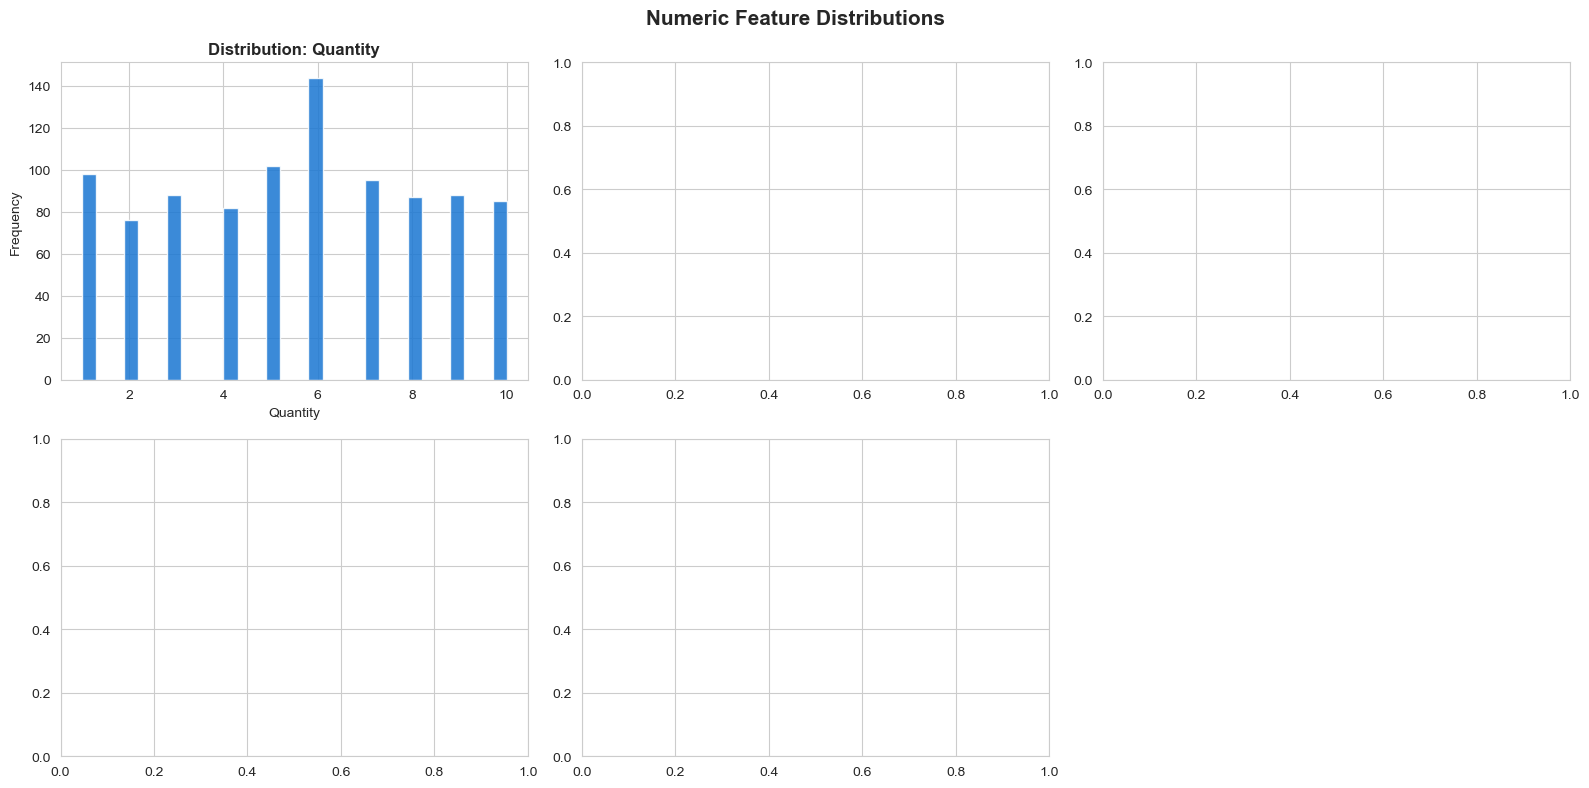

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [22]:
# 3.4 Numeric feature distribution (histograms)
num_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
 axes[i].hist(df_balanced[col], bins=30, color='#1976D2',
 edgecolor='white', alpha=0.85)
 axes[i].set_title(f'Distribution: {col}', fontweight='bold')
 axes[i].set_xlabel(col)
 axes[i].set_ylabel('Frequency')
 axes[5].set_visible(False)
 plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold')
 plt.tight_layout()
 plt.show()

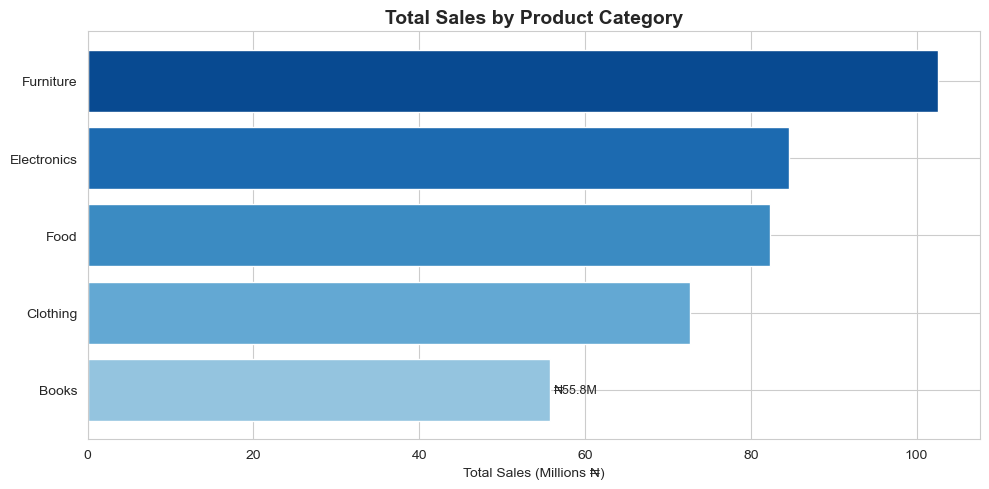

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [47]:
#  STAGE 4 — Exploratory Data Analysis (EDA)
# 4.1 Total Sales by Product Category
cat_sales = df_balanced.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_sales)))
bars = ax.barh(cat_sales.index, cat_sales.values / 1e6, color=colors,
edgecolor='white')
for bar, val in zip(bars, cat_sales.values):
 ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
 f'₦{val/1e6:.1f}M', va='center', fontsize=9)
 ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold')
 ax.set_xlabel('Total Sales (Millions ₦)')
 plt.tight_layout()
 plt.show()

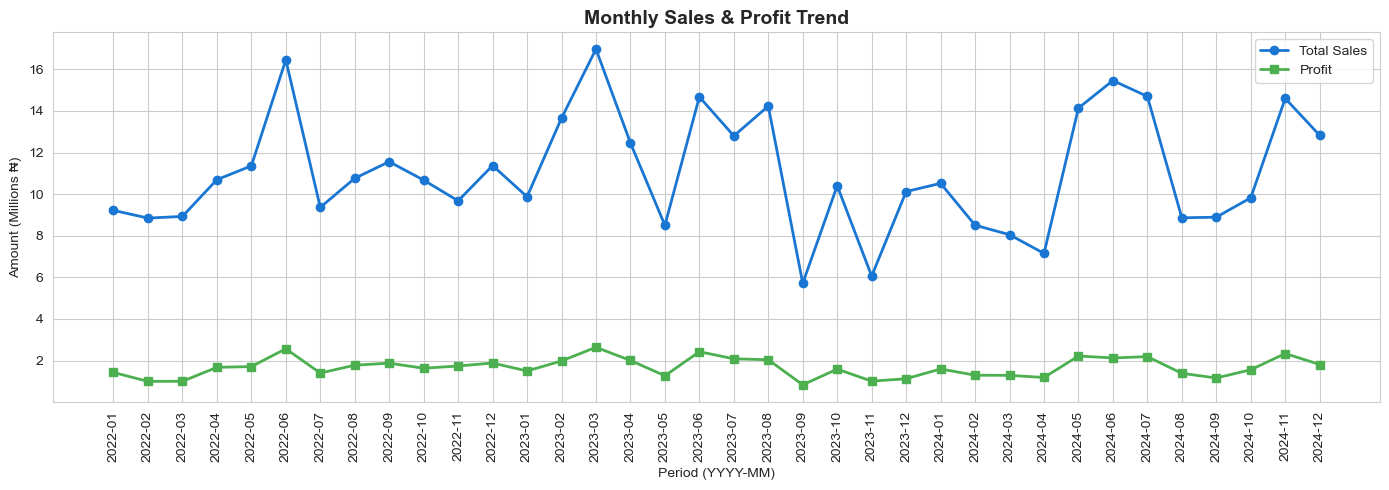

In [23]:
# 4.2 Monthly Sales & Profit Trend
monthly = (df_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']]
.sum().reset_index().sort_values(['Year','Month'])
)
monthly['Period'] =( monthly['Year'].astype(str) + '-' +
monthly['Month'].astype(str).str.zfill(2))
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Total_Sales']/1e6,
marker='o', color='#1976D2', label='Total Sales', linewidth=2)
ax.plot(monthly['Period'], monthly['Profit']/1e6,
marker='s', color='#4CAF50', label='Profit', linewidth=2)
ax.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Period (YYYY-MM)')
ax.set_ylabel('Amount (Millions ₦)')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

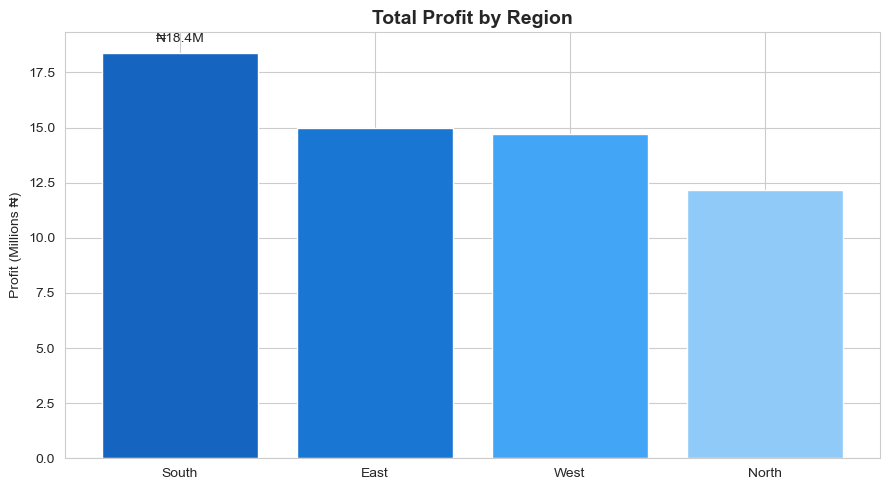

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [24]:
#4.3 Profit by Region
#Which region contributes the highest profit? A simple grouped bar chart answers this question
#clearly.
region_profit =df_balanced.groupby('Region')['Profit'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
palette = ['#1565C0','#1976D2','#42A5F5','#90CAF9']
bars = ax.bar(region_profit.index, region_profit.values/1e6, color=palette,
edgecolor='white')
for bar, val in zip(bars, region_profit.values):
 ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
 f'₦{val/1e6:.1f}M', ha='center', fontsize=10)
 ax.set_title('Total Profit by Region', fontsize=14, fontweight='bold')
 ax.set_ylabel('Profit (Millions ₦)')
 plt.tight_layout()
 plt.show()

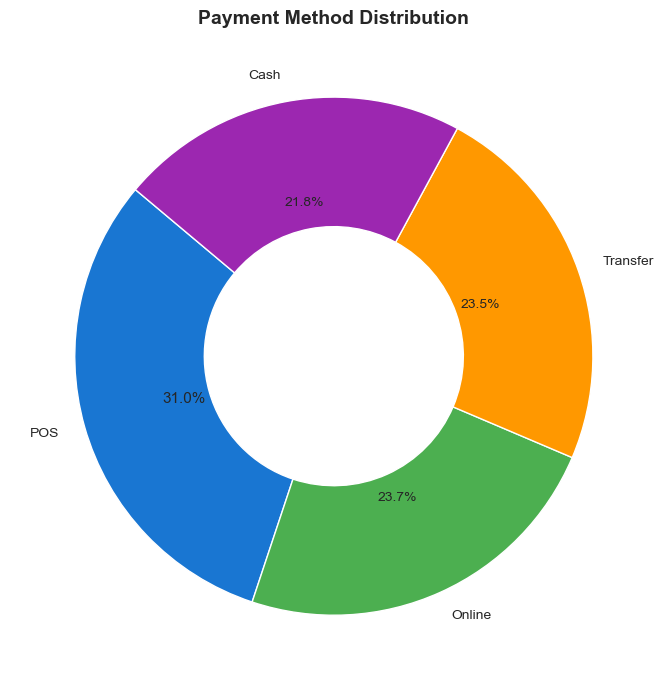

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [26]:
# 4.4 Payment Method Share (Donut Chart)
# A donut chart (pie with hole=0.4) shows the proportion of each payment method. autopct adds
# percentage labels to each slice automatically.
pay_counts = df_balanced['Payment_Method'].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
pay_counts.values,
labels=pay_counts.index,
autopct='%1.1f%%',
startangle=140,
wedgeprops={'width': 0.5},
colors= ['#1976D2','#4CAF50','#FF9800','#9C27B0']
)
for t in autotexts:
 t.set_fontsize(11)
 ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
 plt.tight_layout()
 plt.show()

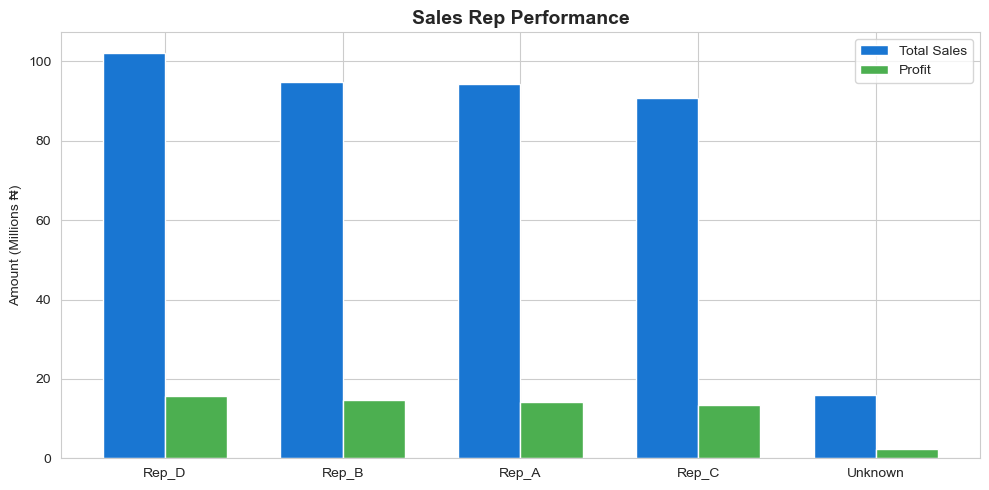

In [52]:
#4.5 Sales Rep Performance
#A grouped bar chart compares each sales rep's total sales vs profit side by side. This helps
#management spot who is selling high but profiting low (possibly due to excessive discounts).
rep_perf = (df_balanced.groupby('Sales_Rep')[['Total_Sales','Profit']]
.sum().sort_values('Total_Sales', ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(rep_perf)), 0.35
ax.bar(x - w/2, rep_perf['Total_Sales']/1e6, width=w, label='Total Sales',
color='#1976D2')
ax.bar(x + w/2, rep_perf['Profit']/1e6, width=w, label='Profit',
color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(rep_perf.index)
ax.set_title('Sales Rep Performance', fontsize=14, fontweight='bold')
ax.set_ylabel('Amount (Millions ₦)')
ax.legend()
plt.tight_layout()
plt.show()

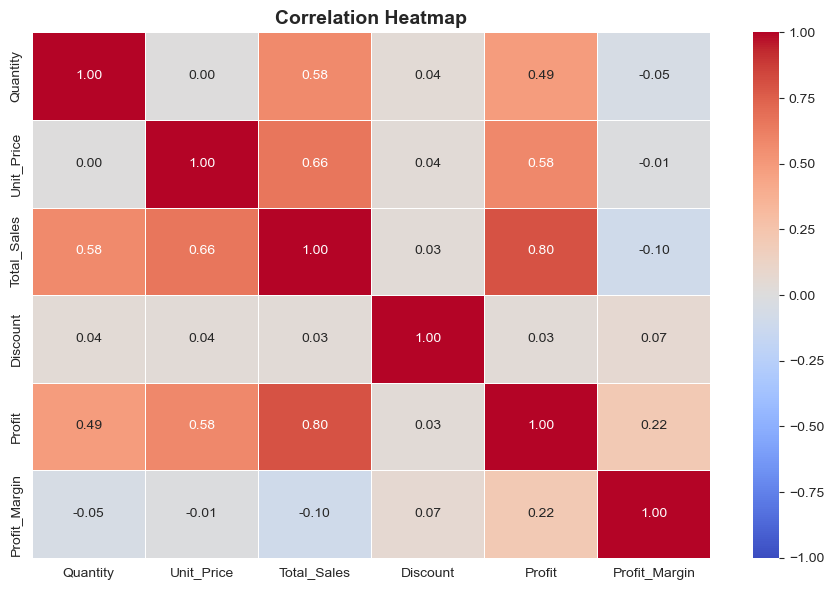

In [27]:
# 4.6 Correlation Heatmap
# A correlation matrix shows how numeric columns relate. Values near +1 = strong positive (both
# go up together). Values near -1 = strong negative. Values near 0 = no relationship.
corr = df_balanced[['Quantity','Unit_Price','Total_Sales',
'Discount','Profit','Profit_Margin']].corr()
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


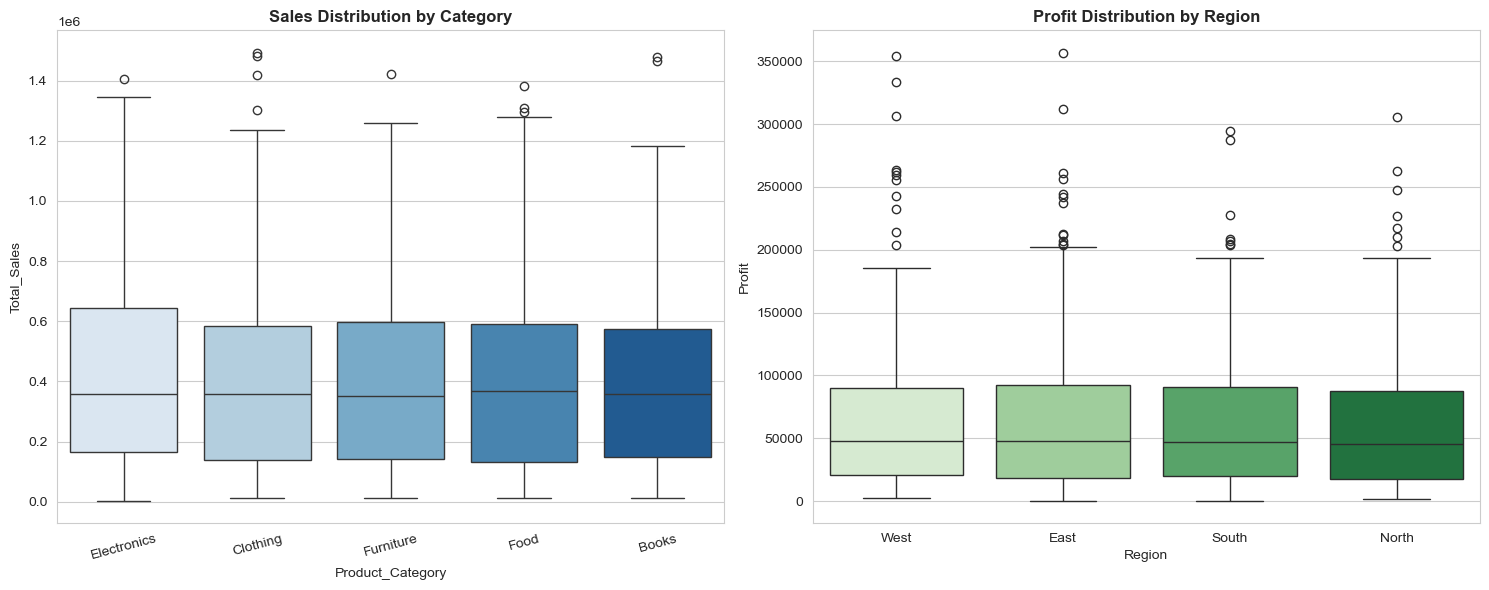

In [54]:
# 4.7 Box Plots: Sales by Category & Region
# Box plots show the median (middle line), spread (box), and outliers (dots beyond the whiskers).
# They reveal whether some categories have much higher variability than others.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=df_balanced, x='Product_Category', y='Total_Sales',
palette='Blues', ax=axes[0])
axes[0].set_title('Sales Distribution by Category', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
sns.boxplot(data=df_balanced, x='Region', y='Profit',
palette='Greens', ax=axes[1])
axes[1].set_title('Profit Distribution by Region', fontweight='bold')
plt.tight_layout()
plt.show()

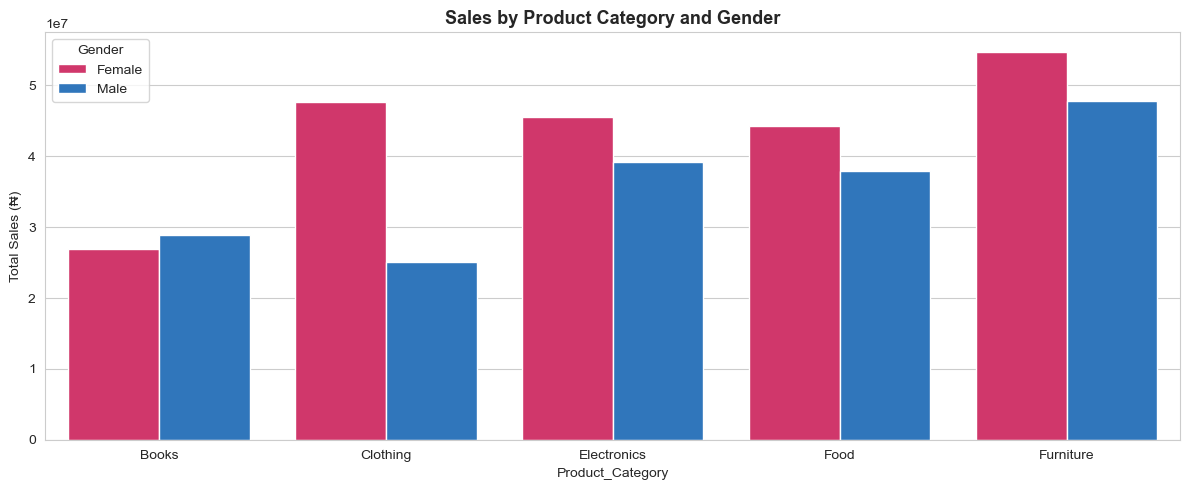

In [56]:
# 4.8 Sales by Gender and Product Category
# hue='Gender' splits each bar into male and female. This lets us see whether purchasing patterns
# differ by gender across product categories.
gender_cat = (df_balanced.groupby(['Gender','Product_Category'])['Total_Sales']
.sum().reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=gender_cat, x='Product_Category', y='Total_Sales',
hue='Gender',
palette={'Female':'#E91E63','Male':'#1976D2'}, ax=ax)
ax.set_title('Sales by Product Category and Gender', fontsize=13,
fontweight='bold')
ax.set_ylabel('Total Sales (₦)')
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

In [28]:
# STAGE 5 — Interactive Dashboard (Plotly)
# 5.1 Prepare summary tables for the dashboard
# We pre-aggregate the data into smaller summary tables. This makes the dashboard code cleaner
#and the charts faster to render.
# Monthly trend
monthly_trend = (df_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']]
.sum().reset_index().sort_values(['Year','Month'])
)
monthly_trend['Period'] = (monthly_trend['Year'].astype(str) + '-'
+ monthly_trend['Month'].astype(str).str.zfill(2))
# Category summary
cat_summary = df_balanced.groupby('Product_Category').agg(
Total_Sales=('Total_Sales','sum'),
Profit=('Profit','sum'),
Orders=('Order_ID','count')
).reset_index()
# Region summary
region_summary = df_balanced.groupby('Region').agg(
Total_Sales=('Total_Sales','sum'),
Profit=('Profit','sum')
).reset_index()
# Sales Rep summary
rep_summary = df_balanced.groupby('Sales_Rep').agg(
Total_Sales=('Total_Sales','sum'),
Profit=('Profit','sum'),
Orders=('Order_ID','count')
).reset_index()
# Payment method
pay_summary = df_balanced['Payment_Method'].value_counts().reset_index()
pay_summary.columns = ['Payment_Method', 'Count']
print(' Summary tables ready!')

 Summary tables ready!


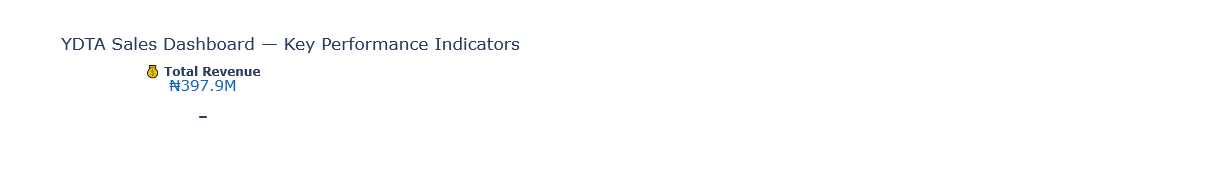

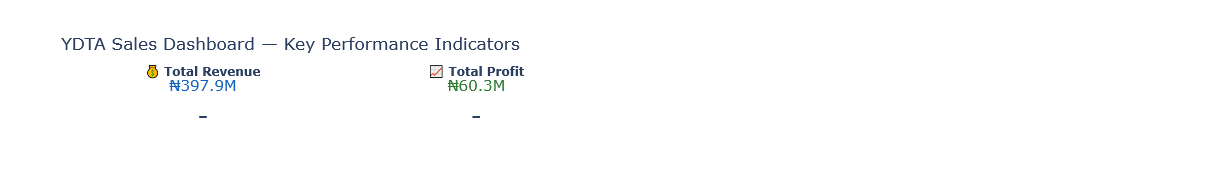

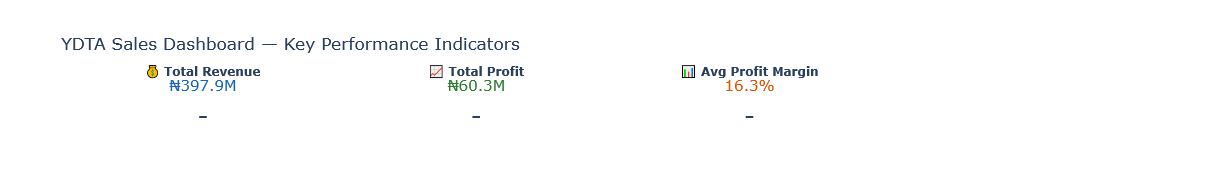

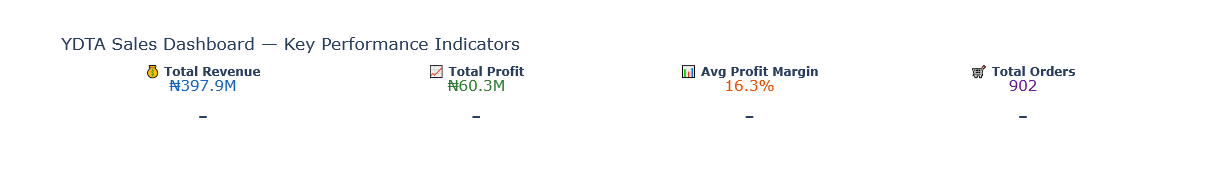

In [29]:
# 5.2 KPI Summary Tiles
# Key Performance Indicators (KPIs) are the headline numbers every dashboard starts with. We
# show Total Revenue, Total Profit, Average Profit Margin, and Total Orders.
total_revenue = df_balanced['Total_Sales'].sum()
total_profit = df_balanced['Profit'].sum()
avg_margin = df_balanced['Profit_Margin'].mean()
total_orders = df_balanced['Order_ID'].nunique()
fig = go.Figure()
kpis = [
('💰 Total Revenue', f'₦{total_revenue/1e6:.1f}M', '#1565C0'),
('📈 Total Profit', f'₦{total_profit/1e6:.1f}M', '#2E7D32'),
('📊 Avg Profit Margin', f'{avg_margin:.1f}%', '#E65100'),
('🛒 Total Orders', f'{total_orders:,}', '#6A1B9A'),
]
for i, (label, value, color) in enumerate(kpis):
 fig.add_trace(go.Indicator(
 mode='number',
 value=None,
 title={'text': f'<b>{label}</b><br>'
 f'<span style="font-size:15px;color:{color}">{value}</span>',
 'font': {'size': 12}},
 domain={'row': 0, 'column': i}
 ))
 fig.update_layout(
 grid={'rows': 1, 'columns': 4},
 height=180,
 title='YDTA Sales Dashboard — Key Performance Indicators',
 margin={'t': 100, 'b': 50}
 )
 fig.show()


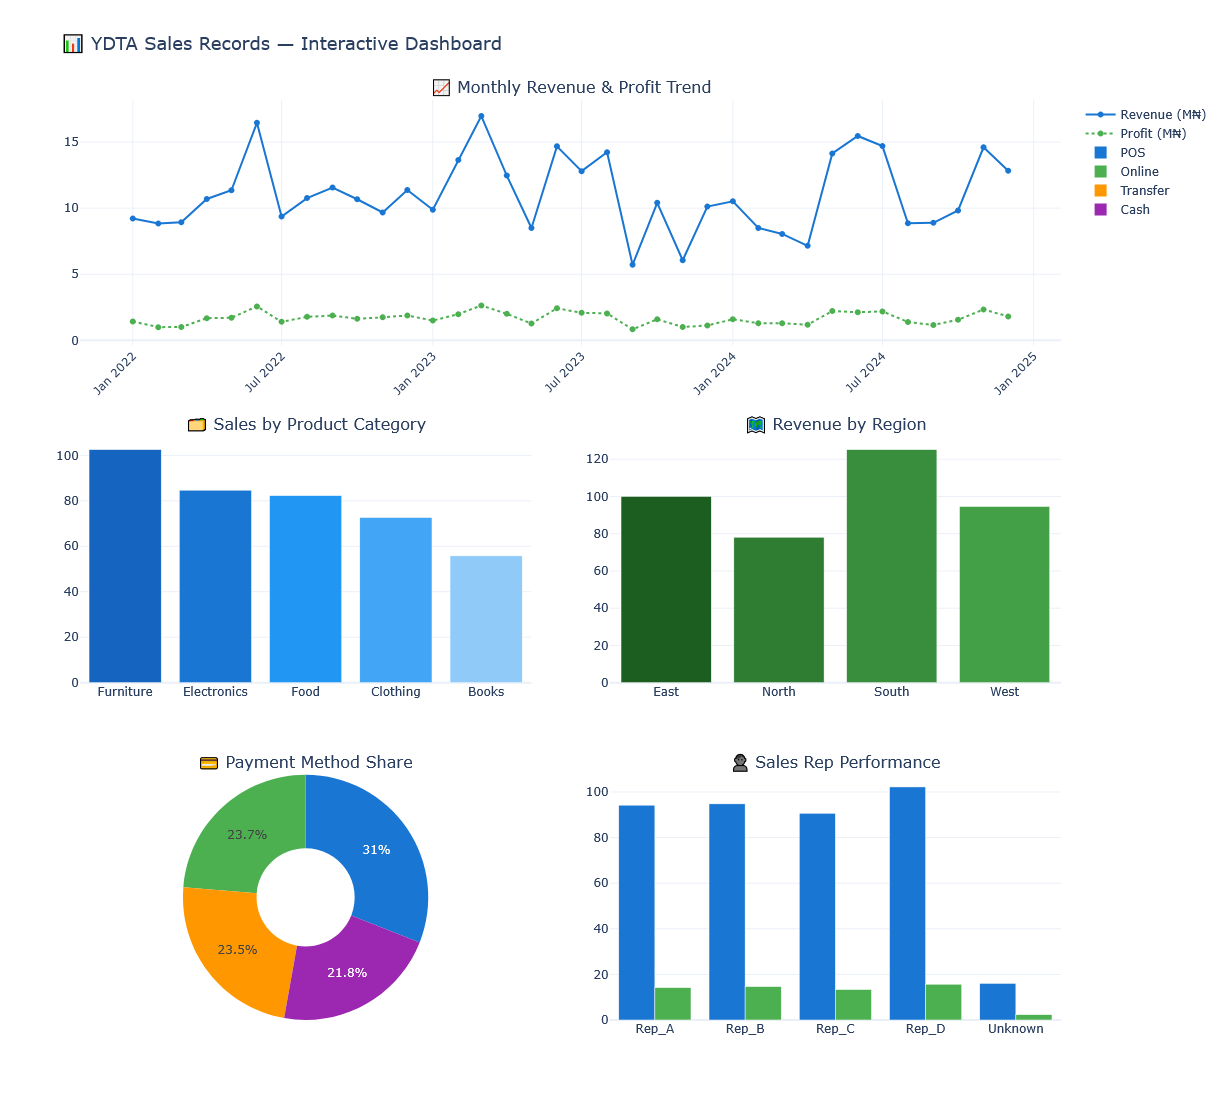

In [31]:
# Main 6-Panel Interactive Dashboard
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        '📈 Monthly Revenue & Profit Trend',
        '🗂️ Sales by Product Category',
        '🗺️ Revenue by Region',
        '💳 Payment Method Share',
        '👤 Sales Rep Performance',
        '🔥 Category vs Region Heatmap'
    ],
    specs=[
        [{'colspan': 2}, None],
        [{}, {}],
        [{'type': 'domain'}, {}]
    ],
    vertical_spacing=0.10,
    horizontal_spacing=0.08
)

# Panel 1: Monthly Trend
fig.add_trace(go.Scatter(
    x=monthly_trend['Period'],
    y=monthly_trend['Total_Sales']/1e6,
    mode='lines+markers',
    name='Revenue (M₦)',
    line=dict(color='#1976D2', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=monthly_trend['Period'],
    y=monthly_trend['Profit']/1e6,
    mode='lines+markers',
    name='Profit (M₦)',
    line=dict(color='#4CAF50', width=2, dash='dot')
), row=1, col=1)

# Panel 2: Category Sales
cat_s = cat_summary.sort_values('Total_Sales', ascending=False)
fig.add_trace(go.Bar(
    x=cat_s['Product_Category'],
    y=cat_s['Total_Sales']/1e6,
    name='Sales by Category',
    marker_color=['#1565C0','#1976D2','#2196F3','#42A5F5','#90CAF9'],
    showlegend=False
), row=2, col=1)

# Panel 3: Region Revenue
fig.add_trace(go.Bar(
    x=region_summary['Region'],
    y=region_summary['Total_Sales']/1e6,
    name='Sales by Region',
    marker_color=['#1B5E20','#2E7D32','#388E3C','#43A047'],
    showlegend=False
), row=2, col=2)

# Panel 4: Payment Method Pie
fig.add_trace(go.Pie(
    labels=pay_summary['Payment_Method'],
    values=pay_summary['Count'],
    hole=0.4,
    marker=dict(colors=['#1976D2','#4CAF50','#FF9800','#9C27B0'])
), row=3, col=1)

# Panel 5: Sales Rep
fig.add_trace(go.Bar(
    x=rep_summary['Sales_Rep'],
    y=rep_summary['Total_Sales']/1e6,
    name='Rep Revenue',
    marker_color='#1976D2',
    showlegend=False
), row=3, col=2)

fig.add_trace(go.Bar(
    x=rep_summary['Sales_Rep'],
    y=rep_summary['Profit']/1e6,
    name='Rep Profit',
    marker_color='#4CAF50',
    showlegend=False
), row=3, col=2)

fig.update_layout(
    height=1100,
    title_text='📊 YDTA Sales Records — Interactive Dashboard',
    title_font_size=18,
    template='plotly_white'
)
fig.update_xaxes(tickangle=-45, row=1, col=1)
fig.show()

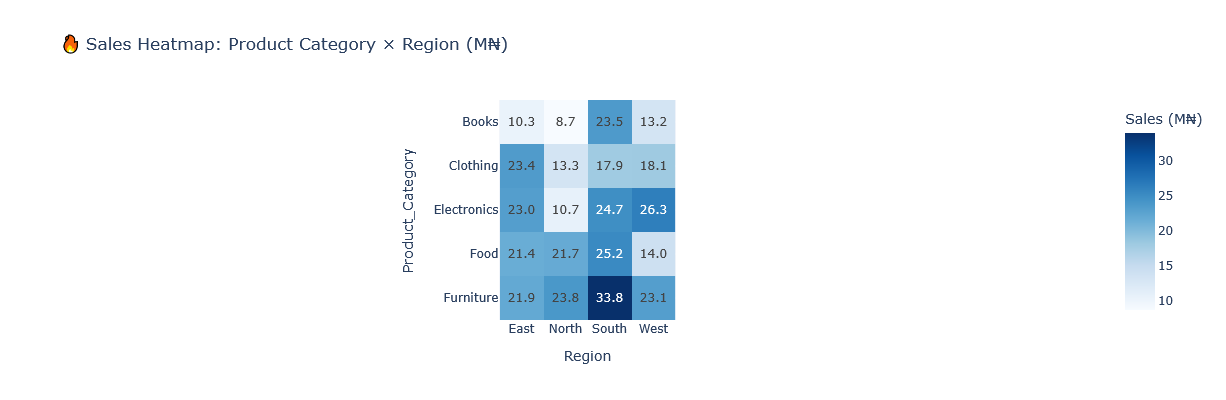

In [34]:

#5.4 Category × Region Heatmap
#A heatmap uses colour intensity to show which product category sells best in which region.
#Darker = higher sales. px.imshow() builds it from a pivot table in one line.

pivot = df_balanced.pivot_table(
values='Total_Sales', index='Product_Category',
columns='Region', aggfunc='sum'
) / 1e6
fig = px.imshow(
pivot, text_auto='.1f',
color_continuous_scale='Blues',
title='🔥 Sales Heatmap: Product Category × Region (M₦)',
labels={'color': 'Sales (M₦)'}
)
fig.update_layout(height=400)
fig.show()

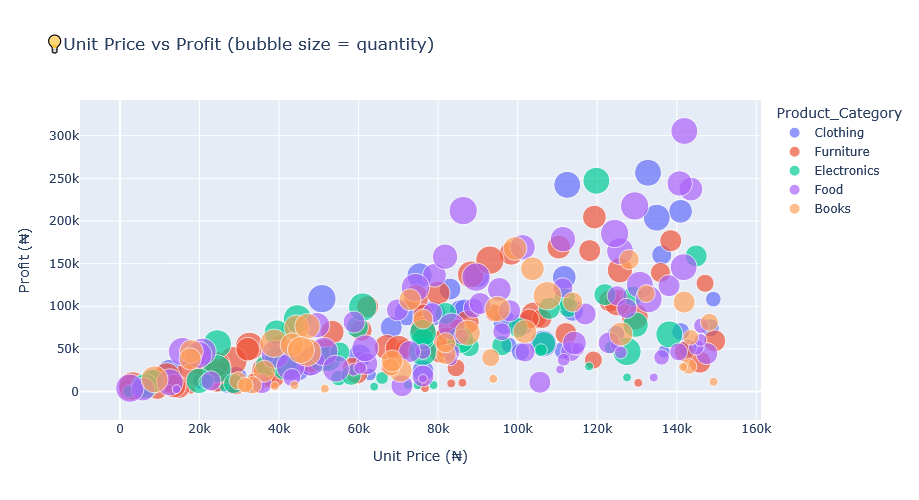

In [91]:
# 5.5 Scatter Plot: Unit Price vs Profit
# Each dot is one order. Colour = product category. Size = quantity sold. Hover over dots to see
# customer name, region, and rep. This reveals which price ranges are most profitable.

fig = px.scatter(
df_balanced.sample(300, random_state=42),
x='Unit_Price', y='Profit',
color='Product_Category',
size='Quantity',
hover_data=['Customer_Name','Region','Sales_Rep'],
title='💡Unit Price vs Profit (bubble size = quantity)',
labels={'Unit_Price':'Unit Price (₦)', 'Profit':'Profit (₦)'}
)
fig.update_layout(height=500)
fig.show()

In [35]:
# STAGE 6 — Save the Cleaned Dataset
# 6.1 Export cleaned dataset to Excel
# to_excel() writes the DataFrame back to an Excel file. index=False prevents pandas from writing
#the row numbers (0, 1, 2 ...) as an extra column.

output_path = 'sales_records_cleaned.xlsx'
df_balanced.to_excel(output_path, index=False)
print(f' Cleaned dataset saved to: {output_path}')
print( f'Final shape: {df_balanced.shape[0]:,} rows × {df_balanced.shape[1]}columns')

 Cleaned dataset saved to: sales_records_cleaned.xlsx
Final shape: 945 rows × 19columns
